# EDA — Telco Customer Churn

Esta análise exploratória documenta a qualidade dos dados, a distribuição do target e os principais padrões associados ao churn. Nenhuma decisão de modelagem deve ser tomada antes desta etapa.

**Fonte:** IBM Telco Customer Churn / Kaggle. O dataset possui 7.043 clientes e 21 colunas.

**Contexto de negócio:** a formulação do problema (proposta de valor, decisão suportada, stakeholders, métricas e riscos) está no [ML Canvas](../docs/ML_CANVAS.md).


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

IMG_DIR = ROOT / 'docs' / 'img'
IMG_DIR.mkdir(parents=True, exist_ok=True)

from src.data.download import download_dataset

DATA_PATH = download_dataset()
df = pd.read_csv(DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Dimensão e estrutura

In [2]:
print('Shape:', df.shape)
print('Duplicated rows:', df.duplicated().sum())
print('Unique customer IDs:', df['customerID'].nunique())
df.info()

Shape: (7043, 21)
Duplicated rows: 0
Unique customer IDs: 7043
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non

In [3]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(),
}).sort_values(['missing_pct', 'n_unique'], ascending=[False, True])
summary

,dtype,missing,missing_pct,n_unique
gender,object,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Partner,object,0,0.0,2
Dependents,object,0,0.0,2
PhoneService,object,0,0.0,2
PaperlessBilling,object,0,0.0,2
Churn,object,0,0.0,2
MultipleLines,object,0,0.0,3
InternetService,object,0,0.0,3
OnlineSecurity,object,0,0.0,3


## 2. Tratamento inicial a investigar

`TotalCharges` chega como texto no arquivo original. Antes de convertê-la para numérico, contabilizamos strings vazias/espaços para não mascarar um problema de qualidade de dados.

In [4]:
total_charges_raw = df['TotalCharges'].astype(str)
blank_total_charges = total_charges_raw.str.strip().eq('').sum()
print('TotalCharges vazios:', blank_total_charges)

df['TotalCharges_numeric'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('NaN após conversão:', df['TotalCharges_numeric'].isna().sum())

df.loc[df['TotalCharges_numeric'].isna(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

TotalCharges vazios: 11
NaN após conversão: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


## 3. Target: Churn

Vamos verificar a proporção de classes. O desbalanceamento será considerado na validação e na escolha das métricas.

In [5]:
target_dist = (df['Churn'].value_counts(dropna=False).rename_axis('Churn').to_frame('count'))
target_dist['pct'] = target_dist['count'] / len(df) * 100
target_dist

,count,pct
Churn,,
No,5174,73.463013
Yes,1869,26.536987


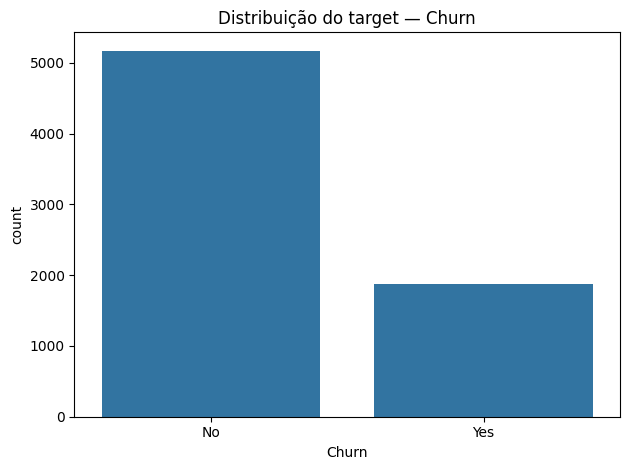

In [6]:
sns.countplot(data=df, x='Churn')
plt.title('Distribuição do target — Churn')
plt.tight_layout()
plt.savefig(IMG_DIR / 'churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Variáveis numéricas

`tenure`, `MonthlyCharges` e `TotalCharges` são os principais campos quantitativos. A relação entre eles e churn será explorada sem eliminar outliers automaticamente.

In [7]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges_numeric']
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges_numeric,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


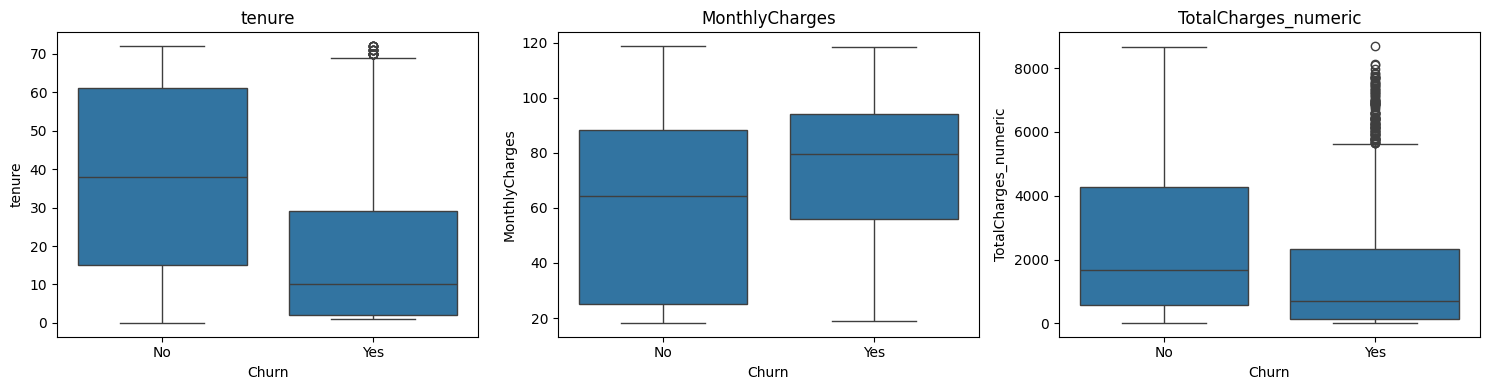

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(IMG_DIR / 'numeric_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Variáveis categóricas e churn rate

Para cada variável categórica, calculamos a taxa de churn por categoria. Isso orientará o feature engineering e a interpretação do modelo.

In [9]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')

for col in categorical_cols:
    rates = (df.groupby(col, dropna=False)['Churn']
             .apply(lambda s: (s == 'Yes').mean() * 100)
             .sort_values(ascending=False))
    print(f'\n### {col}')
    display(rates.round(2).to_frame('churn_pct'))


### gender


,churn_pct
gender,
Female,26.92
Male,26.16



### Partner


,churn_pct
Partner,
No,32.96
Yes,19.66



### Dependents


...

,churn_pct
PaymentMethod,
Electronic check,45.29
Mailed check,19.11
Bank transfer (automatic),16.71
Credit card (automatic),15.24



### TotalCharges


,churn_pct
TotalCharges,
100.25,100.0
97.1,100.0
96.45,100.0
971.3,100.0
973.25,100.0
...,...
3801.7,0.0
3801.3,0.0
38.8,0.0



### Churn


,churn_pct
Churn,
Yes,100.0
No,0.0


## 6. Relações de negócio prioritárias

Contrato, serviço de internet, método de pagamento e tenure são candidatos naturais a investigação porque representam vínculo, oferta e comportamento de permanência.

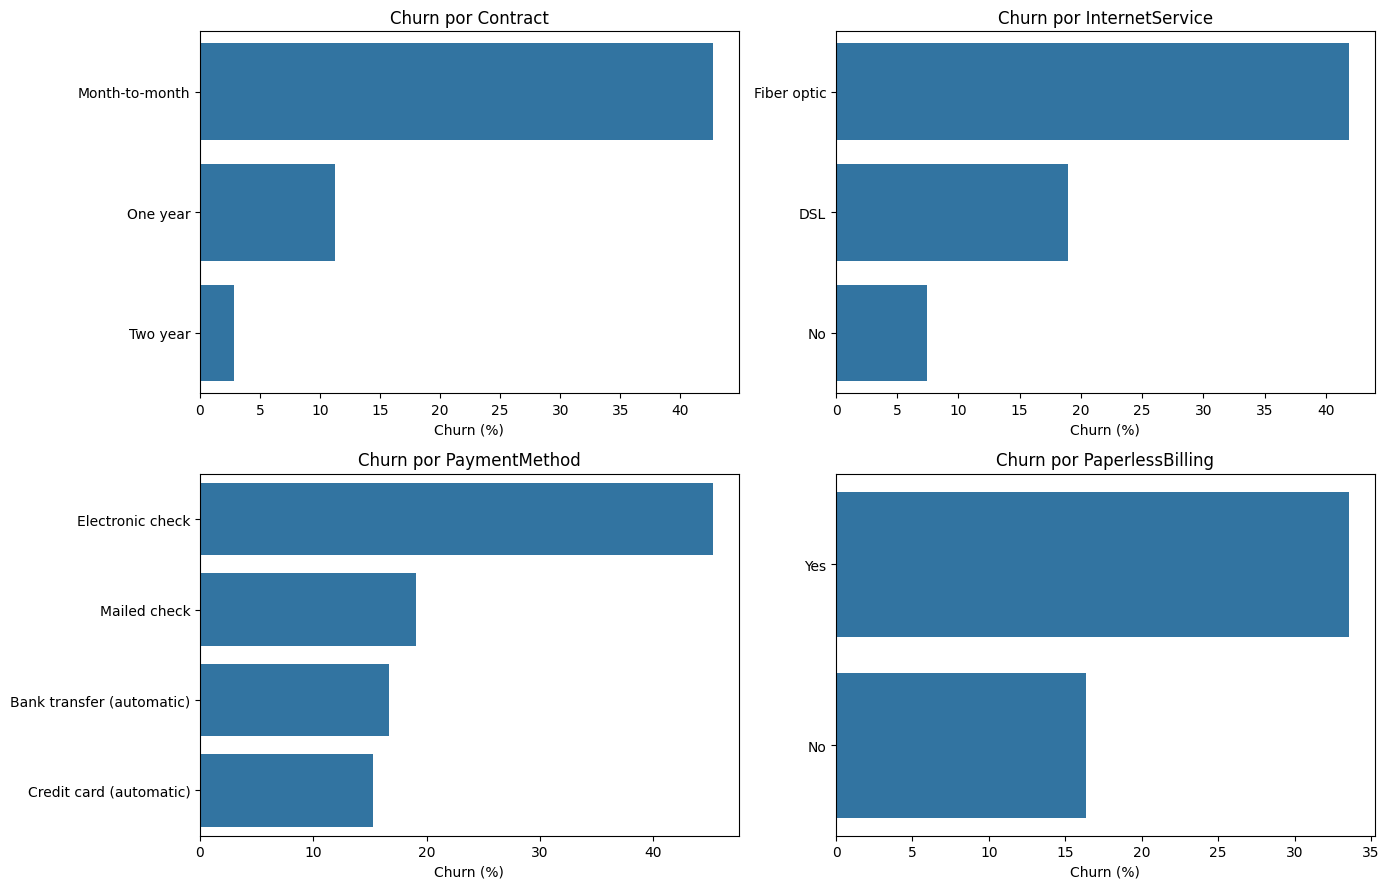

In [10]:
business_cols = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), business_cols):
    rates = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax)
    ax.set_title(f'Churn por {col}')
    ax.set_xlabel('Churn (%)')
    ax.set_ylabel('')
plt.tight_layout()
plt.savefig(IMG_DIR / 'churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
df['tenure_bin'] = pd.cut(
    df['tenure'],
    bins=[-1, 3, 6, 12, 24, 48, 72],
    labels=['0-3', '4-6', '7-12', '13-24', '25-48', '49-72'],
)
tenure_churn = df.groupby('tenure_bin', observed=False)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)
tenure_churn.round(2).to_frame('churn_pct')

,churn_pct
tenure_bin,
0-3,56.21
4-6,44.63
7-12,35.89
13-24,28.71
25-48,20.39
49-72,9.51


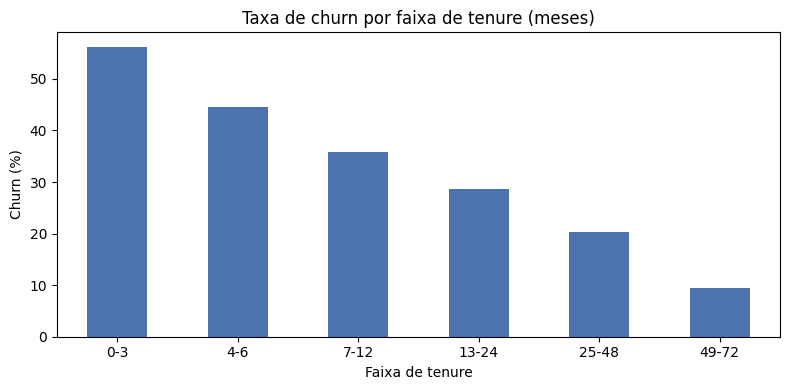

In [12]:
ax = tenure_churn.plot(kind='bar', color='#4c72b0', figsize=(8, 4))
ax.set_title('Taxa de churn por faixa de tenure (meses)')
ax.set_xlabel('Faixa de tenure')
ax.set_ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(IMG_DIR / 'churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Hipóteses para modelagem

Ao final da EDA, registrar hipóteses verificáveis em vez de conclusões causais. Exemplos: clientes em contratos mensais podem apresentar maior churn; menor tenure pode estar associado a maior risco; determinados métodos de pagamento podem concentrar churn.

Essas hipóteses serão testadas pelos modelos e pelas métricas, não tratadas como causalidade.

## 8. Próximos passos

1. Definir o tratamento de `TotalCharges` com base na evidência encontrada.
2. Separar treino/teste de forma estratificada antes de aprender transformações.
3. Construir um `ColumnTransformer` dentro de um `Pipeline`.
4. Treinar Regressão Logística como baseline.
5. Comparar Random Forest e `MLPClassifier` com validação cruzada.


## 8. Baseline — Regressão Logística

A EDA encerra com o baseline treinado pelo mesmo pipeline usado nos experimentos
(`src/models/baseline.py`), para registrar o ponto de partida das métricas.

In [13]:
from src.models.baseline import train_baseline

_, baseline_metrics = train_baseline()
display(pd.Series(baseline_metrics).to_frame('valor'))

,valor
threshold,0.5
roc_auc,0.841298
f1,0.613613
precision,0.504303
recall,0.783422
accuracy,0.738112
confusion_matrix,"[[747, 288], [81, 293]]"
